# LSTM sentiment classification demo

A bidirectional LSTM classifier on the public Rotten Tomatoes sentence-polarity dataset. This notebook builds a vocabulary, trains the model for a few epochs, and reports test accuracy with a confusion matrix. If the dataset cannot be downloaded, the same pipeline runs on a built-in synthetic corpus.

In [1]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.utils.data import DataLoader

from sentlstm.data import (
    build_dataset,
    collate_batch,
    load_rotten_tomatoes,
    synthetic_sentiment,
)
from sentlstm.models import LSTMClassifier
from sentlstm.tokenizer import Vocabulary
from sentlstm.train import Trainer, accuracy, set_seed

set_seed(0)

## Load data

We try the real Rotten Tomatoes corpus first and fall back to the offline synthetic corpus if the download is unavailable, so the notebook always runs.

In [2]:
try:
    (train_texts, train_labels), (test_texts, test_labels) = load_rotten_tomatoes()
    source = 'rotten_tomatoes (real)'
except Exception as exc:
    print(f'download unavailable ({exc}); using synthetic corpus')
    train_texts, train_labels = synthetic_sentiment(repeats=40)
    test_texts, test_labels = synthetic_sentiment(repeats=10, seed=1)
    source = 'synthetic (offline)'

print('source:', source)
print('train sentences:', len(train_texts), '| test sentences:', len(test_texts))
for t, y in zip(train_texts[:3], train_labels[:3]):
    print(f'  [{y}] {t[:70]}')

H:\Projects_for_Github\_portfolio\text-sentiment-lstm\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


source: rotten_tomatoes (real)
train sentences: 8530 | test sentences: 1066
  [1] the rock is destined to be the 21st century's new " conan " and that h
  [1] the gorgeously elaborate continuation of " the lord of the rings " tri
  [1] effective but too-tepid biopic


## Build vocabulary and datasets

In [3]:
vocab = Vocabulary().build(train_texts)
train_set = build_dataset(train_texts, train_labels, vocab)
test_set = build_dataset(test_texts, test_labels, vocab)
print('vocabulary size:', len(vocab))

vocabulary size: 8971


## Train the bidirectional LSTM

Embeddings are trained from scratch here. Pass a GloVe file to `build_embedding_matrix` to warm-start them instead.

In [4]:
model = LSTMClassifier(len(vocab), embed_dim=100, hidden_dim=128)
trainer = Trainer(model, lr=1e-3)
trainer.fit(train_set, test_set, epochs=6, batch_size=64)
print('best test accuracy:', round(max(trainer.history['test_acc']), 4))

epoch   1  train_loss=0.6689  test_acc=0.6069


epoch   2  train_loss=0.5667  test_acc=0.6932


epoch   3  train_loss=0.4278  test_acc=0.6857


epoch   4  train_loss=0.2889  test_acc=0.7158


epoch   5  train_loss=0.1622  test_acc=0.7233


epoch   6  train_loss=0.0860  test_acc=0.7326
best test accuracy: 0.7326


## Accuracy curve

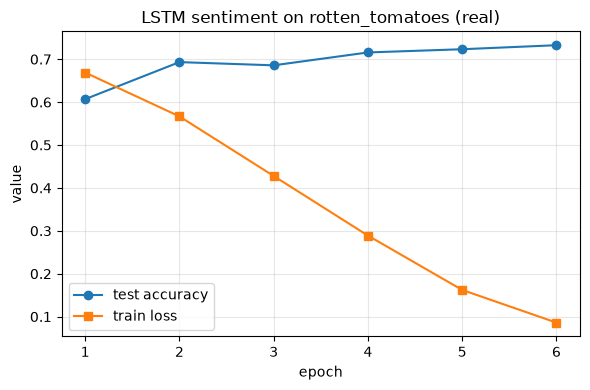

In [5]:
epochs = range(1, len(trainer.history['test_acc']) + 1)
plt.figure(figsize=(6, 4))
plt.plot(epochs, trainer.history['test_acc'], marker='o', label='test accuracy')
plt.plot(epochs, trainer.history['train_loss'], marker='s', label='train loss')
plt.xlabel('epoch')
plt.ylabel('value')
plt.title(f'LSTM sentiment on {source}')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Confusion matrix

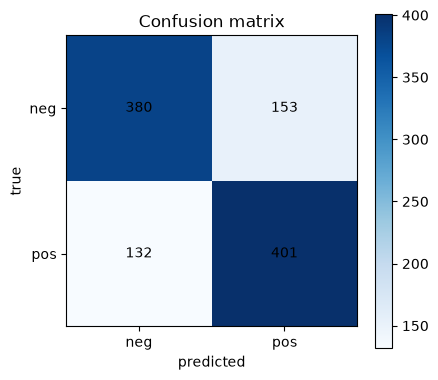

test accuracy: 0.7326


In [6]:
loader = DataLoader(test_set, batch_size=64, collate_fn=collate_batch)
cm = np.zeros((2, 2), dtype=int)
model.eval()
with torch.no_grad():
    for ids, lengths, labels in loader:
        pred = model(ids, lengths).argmax(dim=1).numpy()
        for t, p in zip(labels.numpy(), pred):
            cm[t, p] += 1

fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1], ['neg', 'pos'])
ax.set_yticks([0, 1], ['neg', 'pos'])
ax.set_xlabel('predicted')
ax.set_ylabel('true')
ax.set_title('Confusion matrix')
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha='center', va='center')
fig.colorbar(im)
plt.tight_layout()
plt.show()

print('test accuracy:', round(accuracy(model, loader), 4))

## Try it on new sentences

In [7]:
samples = [
    'a beautifully acted and deeply moving film',
    'a boring, predictable mess with no redeeming qualities',
    'the story dragged but the visuals were stunning',
]
model.eval()
with torch.no_grad():
    for s in samples:
        ids, lengths, _ = collate_batch([(vocab.encode(s), 0)])
        prob = torch.softmax(model(ids, lengths), dim=1)[0]
        label = 'positive' if prob[1] > prob[0] else 'negative'
        print(f'{label} ({prob[1]:.2f}): {s}')

positive (1.00): a beautifully acted and deeply moving film
negative (0.00): a boring, predictable mess with no redeeming qualities
negative (0.10): the story dragged but the visuals were stunning
